# Sprint 19 - Aprendizaje por Refuerzo (Ejercicios)

En estos ejercicios profundizaremos en el campo del **aprendizaje por refuerzo** mediante el estudio de un nuevo algoritmo: la **Red Profunda Q (DQN)**. Este método representa una evolución del tradicional **Q-Learning**, incorporando el poder de las **redes neuronales** para resolver problemas donde la complejidad es significativa.

Como recordarás, el objetivo del aprendizaje por refuerzo consiste en que un agente aprenda a tomar decisiones óptimas a través de la interacción con un entorno. En el caso del **Q-Learning**, este aprendizaje se basa en estimar la utilidad esperada (q-valores) de ejecutar una determinada acción en un estado específico. Sin embargo, cuando los entornos se vuelven más complejos, el número de combinaciones estado-acción puede crecer rápidamente, haciendo que almacenar y actualizar toda esta información resulte computacionalmente costoso. Es precisamente aquí donde las redes neuronales aportan una solución efectiva.

La principal innovación del **DQN** consiste en reemplazar la tabulación que contiene los q-valores por una red neuronal capaz de aproximar estas estimaciones. Gracias a ello, el agente puede generalizar conocimientos adquiridos en situaciones previas y aplicarlos a estados similares que nunca había observado anteriormente. Esta capacidad de generalización permite abordar problemas mucho más complejos y cercanos a escenarios reales, donde las posibilidades de interacción suelen ser prácticamente infinitas.

Para poner en práctica estos conceptos, volveremos a trabajar con nuestra "mini-ciudad" del documento **S19_Aprendizaje_Refuerzo_Sesiones**, implementándola mediante una *clase* para representar de manera estructurada tanto el entorno como los elementos que interactúan dentro de él. Sobre este escenario implementaremos un modelo basado en **DQN** cuyo objetivo será permitir que el vehículo aprenda rutas eficientes para desplazarse desde un punto de origen hasta un destino objetivo. Durante el entrenamiento, el agente deberá descubrir qué decisiones le permiten aumentar su probabilidad de éxito y reducir simultáneamente el tiempo necesario para completar cada recorrido.

De forma complementaria, estudiaremos los fundamentos teóricos que hacen posible el funcionamiento del **DQN**. En particular, exploraremos cómo las redes neuronales pueden utilizarse para aproximar y resolver problemas complejos, y por qué esta combinación de lógicas ha resultado tan exitosa en los últimos años, constituyéndose en la base de numerosos avances modernos en el ámbito tecnológico. Lo expuesto nos servirá para adentrarnos aún más al denominado **aprendizaje profundo**, una disciplina que ha revolucionado campos como la toma de decisiones automatizada y la interacción humano-máquina. En este sentido, con esta práctica adquirirás una visión más amplia sobre las técnicas que actualmente impulsan muchas de las aplicaciones más avanzadas de inteligencia artificial en el mundo real.

## Creación de entorno y modelo base

### Ejericicio 1

Carga las librerías, módulos y funciones necesarias, incluyendo lo siguiente:

* **Pandas**, **numpy** y **matplotlib** para manipulación y visualización de datos.
* **Gymnasium** para creación de entornos.
* **Torch** para contar con funciones que permitan manipular datos en el contexto de redes neuronales.
* El módulo `nn` de **torch** para diseñar y manipular libremente redes neuronales.
* La función `deque` de la librería **collections** que nos permite contar con listas de tamaño fijo. 

In [1]:
# Cargar librerias para manipulacion y visualizacion de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar librerias para modelamiento 
import gymnasium as gym
import torch
from torch import nn
from collections import deque

Define una clase donde se establezca el entorno de una "mini-ciudad", exactamente igual a lo realizado en el documento **S19_Aprendizaje_Refuerzo_Sesiones**. Solamente flexibiliza la condicion de para por cumplimiento de tiempo limite tal que se indique `end_time = self.time >= self.size ** 2 // 2` donde corresponda.

In [2]:
class CityEnv():

    # Definir caracteristicas del entorno
    def __init__(self, size = 10):

        self.size = int(size)
        self.time = 0
 
        self.vehicle = np.array([self.size // 2, self.size // 2])
        self.target = np.array([self.size // 2, self.size // 2])

        self.action_space = gym.spaces.Discrete(4)
        self.action_representation = {
            0: np.array([1,0]),
            1: np.array([0,1]),
            2: np.array([-1,0]),
            3: np.array([0,-1]),
        }

        self.state_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                ),   
                "target": gym.spaces.Box(
                    low = 0, 
                    high = self.size - 1, 
                    shape = (2,), 
                    dtype = int
                )
            }
        )
    
    # Definir metodo para extraer estado
    def get_state(self):
        return {"vehicle": self.vehicle, "target": self.target}
    
    # Establecer metodo para generar informacion de distancias entre agentes
    def get_dist(self):
        return np.linalg.norm(self.vehicle - self.target, ord = 1)

    # Definir metodo de inicializacion de entorno
    def initialize(self):

        self.time = 0

        self.vehicle = np.random.randint(
            low = 0, 
            high = self.size, 
            size = 2
        )

        self.target = self.vehicle
        while np.array_equal(self.target, self.vehicle):
            self.target = np.random.randint(
                low = 0, 
                high = self.size, 
                size = 2
            )

        state = self.get_state()
        distance = self.get_dist()

        return state, distance
    
    # Definir metodo de actualizacion de entorno
    def step(self, action):
        
        direction = self.action_representation[action]

        self.vehicle = np.clip(
            self.vehicle + direction, 
            a_min = 0, 
            a_max = self.size - 1
        )

        end_steps = np.array_equal(self.vehicle, self.target)

        self.time = self.time + 1
        end_time = self.time >= self.size ** 2 // 2

        reward = 1 if end_steps else 0

        state = self.get_state()
        distance = self.get_dist()

        return state, reward, end_steps, end_time, distance

Igualmente, crea una función que permita visualizar el entorno.

In [3]:
# Definir funcion para visualizar entorno
def graf_grid (size, time, dist, start_state, state, trace = np.zeros(2) - 1):

    plt.figure(figsize = [5,5])

    # Visualizar punto de origen
    plt.scatter(x = start_state["vehicle"][0], y = start_state["vehicle"][1], marker = "*", s = 80, color = "gray")

    # Visualizar posicion del vehiculo
    plt.scatter(x = start_state["target"][0], y = start_state["target"][1], marker = "x", s = 80, color = "tomato")

    # Visualizar ruta tomada por el vehiculo
    if not np.array_equal(np.zeros(2) - 1, np.array(trace)):
        plt.plot(trace[:,0], trace[:,1], color = "dodgerblue", linestyle = ":")

    # Visualizar posicion del objetivo
    plt.scatter(x = state["vehicle"][0], y = state["vehicle"][1], marker = "$V$", s = 25, color = "dodgerblue")

    # Formatear visualizacion
    plt.title(f"Time: {time:.0f} - Distance: {dist:.0f}")
    plt.xticks(ticks = range(size))
    plt.xlim([-1, size])
    plt.yticks(ticks = range(size))
    plt.ylim([-1, size])
    plt.grid(linestyle = ":")
    plt.show()

### Ejercicio 2

Genera un entorno de tamaño 5, y guárdalo en la variable `env`. 

In [4]:
env = CityEnv(size = 5)

Para verificar que el entorno sea correcto has una prueba inicializándolo.

Posicion vehiculo: [3 2]
Posicion objetivo: [0 4]
Distancia: 5.0
Tiempo transcurrido: 0


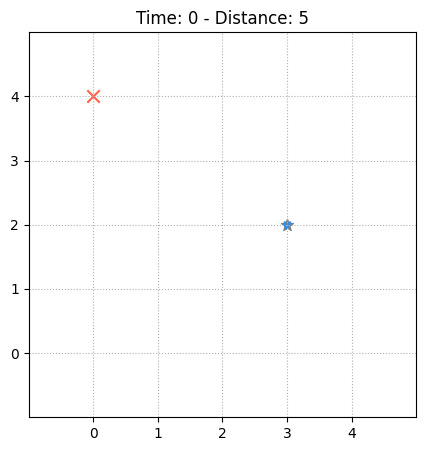

In [5]:
state, dist = env.initialize()
print(f"Posicion vehiculo: {state["vehicle"]}")
print(f"Posicion objetivo: {state["target"]}")
print(f"Distancia: {dist}")
print(f"Tiempo transcurrido: {env.time}")
graf_grid(env.size, env.time, dist, state, state)

Simula en 1,000 ocasiones el funcionamiento del entorno, y guarda la recompensa total de cada iteración y el tiempo de ejecución como porcentaje de la distancia inicial en listas.

In [6]:
# Ejecutar 1000 simulaciones
simulations = 1000
total_reward = []
total_time = []

for _ in range(simulations):

    state, dist_ini = env.initialize()
    reward_sim = 0
    final = False

    while not final:
        action = env.action_space.sample() 
        state, reward, end_sim, end_time, dist = env.step(action)
        final = end_sim or end_time
        reward_sim = reward_sim + reward
    
    total_reward.append(reward_sim)
    total_time.append(env.time / dist_ini - 1)

Calcula la tasa de éxito y el tiempo medio para este modelo básico.

In [7]:
# Calcular tasa de exito y tiempo medio
win_rate = np.mean(total_reward)
tiempo_medio = np.mean(total_time)
print(f"Tasa de exito: {win_rate:.1%}")
print(f"Tiempo medio: {tiempo_medio:.1%}")

Tasa de exito: 25.3%
Tiempo medio: 287.3%


## Creación de modelo con algoritmo DQN

### Ejercicio 1

Como ya se mencionó, el algoritmo **DQN** funciona combinando las ventajas de los q-valores para estimar estrategias óptimas, con la capacidad predictiva de las redes neuronales. De hecho esta técnica utiliza 2 de ellas simultaneamente que ya explicaremos más adelante. En todo caso, la idea subyacente aquí es utilizar estas redes para pronosticar los q-valores de cada acción a partir del estado observado en cada momento de tiempo.

Ante esto, en una primera instancia construyamos algunos componentes fundamentales que necesitaremos.

Inicia definiendo una clase `DQN` que herede los métodos y atributos de cualquier red neuronal de **torch**. Incorpora para esto lo siguiente:

* En los paréntesis luego del nombre de la clase especifica el argumento `nn.Module` que permite heredar los **métodos** del módulo `nn`.
* En la función `__init__` incorpora el código `super().__init__()` que permite heredar los **atributos** del módulo `nn`.

Adicionalmente, esta clase debe recibir 3 entradas: el número de estados posibles en el entorno, las unidades deseadas en una capa densa de una red neuronal, y el número de acciones del entorno.

In [8]:
class DQN(nn.Module): # Se heredan los metodos de una red neuronal de torch

    # Definir atributos de la clase
    def __init__(self, n_states, units, n_actions):
        
        super().__init__() # Se heredan los atributos de una red neuronal de torch

Modifica el código anterior incorporando también los siguientes atributos en `__init__`: 

* Una capa densa con la función `nn.Linear` de **torch** que reciba como entrada el argumento de número de estados posibles, y devuelva como salida las neuronas establecidas.
* Una segunda capa densa que reciba como entrada dichas neuronas, y devuelva el argumento de número de acciones. 

In [9]:
class DQN(nn.Module):

    # Definir atributos de la clase
    def __init__(self, n_states, units, n_actions):
        
        super().__init__()
    
        self.dl1 = nn.Linear(
            in_features = n_states,
            out_features = units
        )
        
        self.dl2 = nn.Linear(
            in_features = units,
            out_features = n_actions
        )

Modifica una vez más el código anterior incorporando un método llamado `forward` para permitir la ejecución de la red neuronal del algoritmo. Este método debe recibir como entrada un tensor `x` de estados, para luego procesarlo dentro de la primera capa densa de la red neuronal. A continuación, debe pasar este resultado por una capa de activación ReLu, y finalmente devolver un resultado `q` al pasar por la segunda capa densa. Para la activación puedes utilizar la función `nn.functional.relu`.

In [10]:
class DQN(nn.Module):

    # Definir atributos de la clase
    def __init__(self, n_states, units, n_actions):
        
        super().__init__()
    
        self.dl1 = nn.Linear(
            in_features = n_states,
            out_features = units
        )

        self.dl2 = nn.Linear(
            in_features = units,
            out_features = n_actions
        )
    
    # Definir metodo para ejecutar la red neuronal
    def forward (self, x):
        
        x_d1 = self.dl1(x)
        x_act = nn.functional.relu(input = x_d1)
        q = self.dl2(x_act)

        return q

Guarda en una variable la función de pérdida con la que trabajarán las redes neuronales en el algoritmo, que en este caso correponde al Error Cuadrático Medio. Para esto, utiliza la función `nn.MSELoss`.  

In [11]:
loss_fn = nn.MSELoss()

Define la función `opt_method` que devuelva para una red neuronal cualquiera `dqn`, el método de optimización en la etapa de retropropagación. Emplearemos en este caso la técnica *Adam*, que puedes generarla con la función `torch.optim.Adam`, y los argumentos `params = dqn.parameters()` y `lr = 0.001`.  

In [12]:
def opt_method (dqn):
    opt_method = torch.optim.Adam(
        params = dqn.parameters(), 
        lr = 0.001
    )
    return opt_method 

En vista que las redes neuronales de **torch** requieren de tensores para su procesamiento, crea una función que codifique y transforme un estado cualquiera en un tensor uni-dimensional de tipo *one-hot*. Para entender lo solicitado, considera lo siguiente: dado un entorno de tamaño $size$, potencialmente pueden existir $(size^2)^2 $ estados; de todos ellos tomemos por ejemplo el quinto estado posible. Entonces esta función debería devolver el tensor $t_5$ dado por

$$ t_5 = (0\quad 0\quad 0\quad 0\quad 1\quad 0\quad 0\quad ...\quad 0\quad 0\quad) $$

In [13]:
def state_to_input(state, n_states):
    input_tensor = torch.zeros(n_states)
    input_tensor[state] = 1
    return input_tensor

Como te puedes dar cuenta, en este ejercicio hemos diseñado la arquitectura de nuestra red neuronal. Hemos establecido sus capas, su función de pérdida y su mecanismo de optimización.

Antes de proceder con el entrenamiento hay que agregar algo más que es parte fundamental del **DQN**: la **memoria** del modelo.

### Ejercicio 2

El **DQN** realiza su aprendizaje considerando las experiencias de los agentes en el entorno, a fin de reforzar comportamiento exitosos y descartar aquellos que no han sido recompensados de manera positiva. Es por esta razón que conviene generar un objeto capaz de guardar esta memoria; la cual, como la de un humano, es limitada.

Crea entonces la variable `memory` mediante la función `deque` con los argumentos `iterable = []` y `maxlen = 1000`. Este objeto es una lista que no puede exceder de 1,000 elementos. 

In [14]:
memory = deque(iterable = [], maxlen = 1000)

Para facilitar la utilización de esta memoria en el proceso de aprendizaje, establezcamos ciertas operaciones especificas de la misma. Primero, define una función llamada `append_memory` que permita adicionar un conjunto de 5 elementos a modo de tupla en la memoria: el estado actual, la acción, el estado nuevo, la recompensa asociada y un buleano que indique si el intento realizado por el vehículo ha terminado.

In [15]:
def append_memory(current_state, action, new_state, reward, final): 
    memory_elements = (current_state, action, new_state, reward, final)
    memory.append(memory_elements)

Segundo, define la función `sample_memory` que permita reciba como entrada un valor entero, y devuelva una muestra aleatoria de elementos de la memoria correspondientes. 

In [16]:
def sample_memory(n):
    rng = np.random.default_rng()
    sample = rng.choice(memory, size = n)
    return sample

El mecanismo de aprendizaje que utilizaremos se conoce como **Repetición de memoria** y vamos a definirlo en más detalle a medida que avancemos..

### Ejercicio 3

Casi tenemos todo lo necesario para empezar el entrenamiento del modelo. Guarda la cantidad de posibles estados del entorno `n_states`, y la cantidad de posibles acciones en `n_actions`. 

In [17]:
# Establecer cantidad de posibles estados
n_states = (env.size ** 2) ** 2

# Establecer cnatidad de acciones
n_actions = env.action_space.n

Establece también los siguientes hiperparámetros que cumplen una función equivalente a lo visto para el algoritmo **Q-Learning**:

| Hiperparametro | Valor |
| ---- | ---- |
| `epsilon` | 1.0 |
| `delta` | 1/10000 |
| `beta` | 0.95 |
| `epsilon_m` | 0.05 |

Incorpora también estos nuevo hiperparámetros propios del algoritmo **DQN**:

* `nn_sync_steps = 10` que establece cuando se sincronizan las redes neuronales utilizadas. Recuerda que ya mencionamos que este algoritmo utiliza 2.
* `memory_threshold = 50` que establece el umbral de experiencia para activar el mecanismo de aprendizaje de las redes neuronales.

In [18]:
# Establecer hiperparametros
epsilon = 1
beta = 0.95
delta = 1/10000
epsilon_m = 0.05
nn_sync_steps = 10
memory_threshold = 50

Creemos finalmente las redes neuronales con las que trabajaremos y que en un principio serán **IDÉNTICAS**. La primera de ellas se conoce como red de entrenamiento y corresponde a aquella que se modificará continuamente a medida que suceden las simulaciones. La segunda se denomina de referencia y se modificará de una manera distinta que explicaremos a continuación.  

Para crearlas utiliza la clase `DQN` tal que ambas reciban como argumentos `n_states`, `n_states` y `n_actions`, y recuerda hacerlas idénticas.

In [19]:
# Crear red neuronal de entrenamiento
train_nn = DQN(n_states, n_states, n_actions)

# Crear red neuronal de referencia
reference_nn = train_nn
#reference_nn = DQN(n_states, n_states, n_actions)

El ajuste de la red de entrenamiento se dará por retropropagación minimizando la función de perdida. Por tanto crea la variable `optimizer_train` mediante la función `opt_method`.

In [20]:
optimizer_train = opt_method(train_nn)

El ajuste de la red de referencia no se dará por retropropagación sino en base a la lógica dada por la **Ecuación de Bellman**, tal que para el q-valor ($q_{a,s}$) de la acción ($a$) y los estados actual ($s$) y siguiente ($s'$) que realice el agente se tendrá

$$ q_{s,a} = r_{s,a} + \beta \max{(Q_{s'})} $$

donde:

* $r_{s,a}$ es la recompensa obtenida en el estado $s$ y la acción $a$.
* $\beta$ es la tasa de descuento definida como hiperparámetro que toma un valor positivo y menor o igual a 1 cuando se está dando la simulación (0 cuando la simulación ha terminado). 
* $Q_{s'}$ es el vector de q-valores para el estado $s'$.

Visto esto, crea la funcion `optimize_nn` que ejecute el ajuste de ambas redes neuronales. Si gustas puedes replicar este código:

```py
def optimize_nn(mini_memory, train_dqn, reference_dqn):

    # Definir variable para uso de funcion
    n_states = train_dqn.dl1.in_features
    train_q_list = []
    reference_q_list = []

    for current_state, action, new_state, reward, final in mini_memory:

        # Actualizar q-valores para red de referencia
        qval = reward + beta * (1 - final) * reference_dqn(state_to_input(new_state, n_states)).max()
        reference_q = reference_dqn(state_to_input(current_state, n_states)) 
        reference_q[action] = qval
        reference_q_list.append(reference_q)

        # Actualizar q-valores para red de entrenamiento
        train_q = train_dqn(state_to_input(current_state, n_states))
        train_q_list.append(train_q)

    # Optimizar red de entrenamiento
    loss_train = loss_fn(torch.stack(train_q_list), torch.stack(reference_q_list))
    optimizer_train.zero_grad()
    loss_train.backward()
    optimizer_train.step()
```

In [21]:
def optimize_nn(mini_memory, train_dqn, reference_dqn):

    # Definir variable para uso de funcion
    n_states = train_dqn.dl1.in_features
    train_q_list = []
    reference_q_list = []

    for current_state, action, new_state, reward, final in mini_memory:

        # Actualizar q-valores para red de referencia
        qval = reward + beta * (1 - final) * reference_dqn(state_to_input(new_state, n_states)).max()
        reference_q = reference_dqn(state_to_input(current_state, n_states)) 
        reference_q[action] = qval
        reference_q_list.append(reference_q)

        # Actualizar q-valores para red de entrenamiento
        train_q = train_dqn(state_to_input(current_state, n_states))
        train_q_list.append(train_q)

    # Optimizar red de entrenamiento
    loss_train = loss_fn(torch.stack(train_q_list), torch.stack(reference_q_list))
    optimizer_train.zero_grad()
    loss_train.backward()
    optimizer_train.step()

Para concluir este apartado, crea un diccionario de estados posibles en el cual la clave sea una tupla de los pares de posiciones del vehículo y el destino objetivo, y el valor corresponda a un valor secuencial empezando en 0. Recuerda que dado que tenemos una "mini-ciudad" de tamaño 5, los estados posibles son 625.

In [22]:
vehicle_xpos = [x for x in range(env.size)]
vehicle_ypos = [y for y in range(env.size)]
vehicle_xypos = [(x,y) for x in vehicle_xpos for y in vehicle_ypos]
target_xypos = vehicle_xypos
possible_states = tuple([(v,t) for v in vehicle_xypos for t in target_xypos])
dic_ps = {}
for i in range(len(possible_states)):
    dic_ps[possible_states[i]] = i
print(f"Estados posibles: {len(dic_ps)}")

Estados posibles: 625


### Ejercicio 4

Como ya mencionamos antes, para realizar nuestro entrenamiento utilizaremos **Repetición de memoria**. Esta técnica parte de la siguiente lógica:

1. Las redes neuronales de entrenamiento y referencia no se ajustan mientras no se cuente con suficiente experiencia y algún éxito. Tampoco se ajusta el valor $\epsilon$ hasta que se cumpla con estas condiciones.
2. Cuando se cumplan, realizar el ajuste de las redes pero únicamente con una muestra de elementos de la memoria.
3. Además de lo anterior, si se han dado suficientes pasos de entrenamiento, se sincronizan nuevamente las dos redes.

En otras palabras, en cada una de las simulaciones que se realice durante el proceso de aprendizaje necesitamos validar si la cantidad de elementos de la memoria ese mayor o igual a `memory_threshhold`, y si en alguna de las simulaciones ya ejecutadas el vehículo ha alcanzado su objetivo (recompensa de 1).

Cuando estas dos condiciones se cumplan, se debe aplicar la función `optimize_nn` ya definida con una muestra aleatoria de tamaño `memory_threshhold` de la memoria; así como actualizar el valor de $\epsilon$. 

Además en este instante se debe verificar si el número de pasos realizados en el proceso ha superado `nn_sync_steps`. Si esto se cumple, se debe igualar nuevamente la red de referencia a la red de entrenamiento y reiniciar el conteo de pasos.

Mira entonces el siguiente código incompleto para entrenar el modelo. Tu deberás completarlo con estas consideraciones en mente y ejecútarlo.

```py
simulations = 15000
train_reward = []
train_time = []
sync_step_count = 0

for _ in range(simulations):

    # Inicializar el entorno
    current_state, dist_ini = env.initialize()
    current_state_t = tuple([tuple(current_state["vehicle"].tolist()), tuple(current_state["target"].tolist())])
    current_state_p = dic_ps[current_state_t]
    final = False
    reward_sim = 0

    # Ejecutar simulacion y actualizar q-valores
    while not final:

        # Seleccionar una accion con criterio epsilon-codicioso
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = train_nn(state_to_input(current_state_p, n_states)).argmax().item()

        # Ejecutar el paso con la accion seleccionada y actualizar valores
        new_state, reward, end_sim, end_time, dist = env.step(action)
        new_state_t = tuple([tuple(new_state["vehicle"].tolist()), tuple(new_state["target"].tolist())])
        new_state_p = """Aqui debería ir código"""
        final = end_sim or end_time
        reward_sim = reward_sim + reward
        append_memory("""Aqui debería ir código""")
        current_state = new_state
        current_state_t = tuple([tuple(current_state["vehicle"].tolist()),tuple(current_state["target"].tolist())])
        current_state_p = """Aqui debería ir código"""
        sync_step_count = """Aqui debería ir código"""

    
    # Guardar resultados de recompensa y tiempo
    train_reward.append(reward_sim)
    train_time.append(env.time / dist_ini - 1)

    # Ejecutar optimizacion basado en logica de repeticion de memoria
    if len(memory) >= """Aqui debería ir código""" and sum(train_reward) > 0:

        mini_memory = sample_memory("""Aqui debería ir código""")
        optimize_nn("""Aqui debería ir código""")

        # Actualizar epsilon        
        epsilon = max("""Aqui debería ir código""")

        if sync_step_count > """Aqui debería ir código""":
            reference_nn = """Aqui debería ir código"""
            sync_step_count = 0
```

In [23]:
simulations = 15000
train_reward = []
train_time = []
sync_step_count = 0

for _ in range(simulations):

    # Inicializar el entorno
    current_state, dist_ini = env.initialize()
    current_state_t = tuple([tuple(current_state["vehicle"].tolist()), tuple(current_state["target"].tolist())])
    current_state_p = dic_ps[current_state_t]
    final = False
    reward_sim = 0

    # Ejecutar simulacion y actualizar q-valores
    while not final:

        # Seleccionar una accion con criterio epsilon-codicioso
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = train_nn(state_to_input(current_state_p, n_states)).argmax().item()

        # Ejecutar el paso con la accion seleccionada y actualizar valores
        new_state, reward, end_sim, end_time, dist = env.step(action)
        new_state_t = tuple([tuple(new_state["vehicle"].tolist()), tuple(new_state["target"].tolist())])
        new_state_p = dic_ps[new_state_t]
        final = end_sim or end_time
        reward_sim = reward_sim + reward
        append_memory(current_state_p, action, new_state_p, reward, final)
        current_state = new_state
        current_state_t = tuple([tuple(current_state["vehicle"].tolist()),tuple(current_state["target"].tolist())])
        current_state_p = dic_ps[current_state_t]
        sync_step_count = sync_step_count + 1

    
    # Guardar resultados de recompensa y tiempo
    train_reward.append(reward_sim)
    train_time.append(env.time / dist_ini - 1)

    # Ejecutar optimizacion basado en logica de repeticion de memoria
    if len(memory) >= memory_threshold and sum(train_reward) > 0:

        mini_memory = sample_memory(memory_threshold)
        optimize_nn(mini_memory, train_nn, reference_nn)

        # Actualizar epsilon        
        epsilon = max(epsilon - delta, epsilon_m)

        if sync_step_count > nn_sync_steps:
            reference_nn = train_nn
            sync_step_count = 0

Evalúa el rendimiento de este modelo visualizando una media movil de las recompensas alcanzadas en las iteraciones.

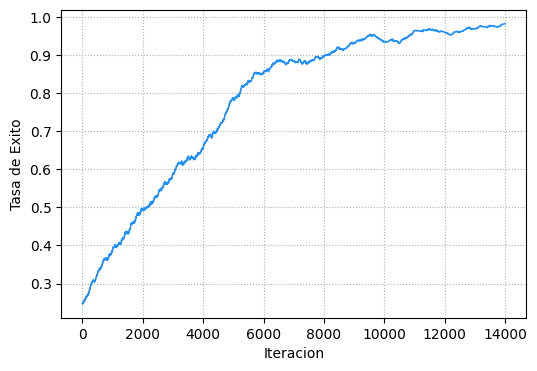

In [24]:
# Visualizar media movil de las recompensas
reward_ma = np.convolve(a = train_reward, v = np.ones(1000), mode = "valid") / 1000
plt.figure(figsize = [6,4])
plt.plot(
    reward_ma,
    color = "dodgerblue",
    linewidth = 1
)
plt.xlabel("Iteracion")
plt.ylabel("Tasa de Exito")
plt.grid(linestyle = ":")
plt.show()

In [25]:
# Obtener tasa de éxito de últimas 1000 iteraciones
print(f"Tasa de exito: {reward_ma[-1]:.1%}")

Tasa de exito: 98.2%


Has lo mismo con el tiempo de las simulaciones relativo a la distancia inicial.

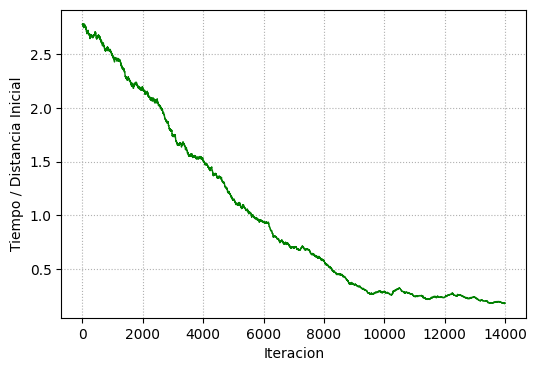

In [26]:
# Visualizar media movil del tiempo medio
time_ma = np.convolve(a = train_time, v = np.ones(1000), mode = "valid") / 1000
plt.figure(figsize = [6,4])
plt.plot(
    time_ma,
    color = "green",
    linewidth = 1
)
plt.xlabel("Iteracion")
plt.ylabel("Tiempo / Distancia Inicial")
plt.grid(linestyle = ":")
plt.show()

In [27]:
# Obtener tiempo medio de últimas 1000 iteraciones
print(f"Tiempo medio: {time_ma[-1]:.1%}")

Tiempo medio: 18.1%


### Ejercicio 5

¡Objetivo conseguido! Vamos a hacer una prueba de nuestro modelo optimizado con **DQN**. Genera una simulación seleccionando la acción en base a este modelo y con completa "explotación".

In [28]:
# Inicializar el entorno
orig_state, dist_ini = env.initialize()
orig_state_t = tuple([tuple(orig_state["vehicle"].tolist()), tuple(orig_state["target"].tolist())])
orig_state_p = dic_ps[current_state_t]
trace = [orig_state["vehicle"].tolist()]
final = False

# Ejecutar simulacion y actualizar q-valores
while not final:

    # Seleccionar una accion con completa explotación
    with torch.no_grad():
        action = train_nn(state_to_input(current_state_p, n_states)).argmax().item()

    # Ejecutar el paso con la accion seleccionada y actualizar valores
    state, reward, end_sim, end_time, dist = env.step(action)
    new_state_t = tuple([tuple(state["vehicle"].tolist()), tuple(state["target"].tolist())])
    new_state_p = dic_ps[new_state_t]
    final = end_sim or end_time
    current_state = state
    current_state_t = tuple([tuple(current_state["vehicle"].tolist()),tuple(current_state["target"].tolist())])
    current_state_p = dic_ps[current_state_t]
    trace.append(current_state["vehicle"].tolist())

Para terminar, visualiza el recorrido con la función auxiliar creada al inicio.

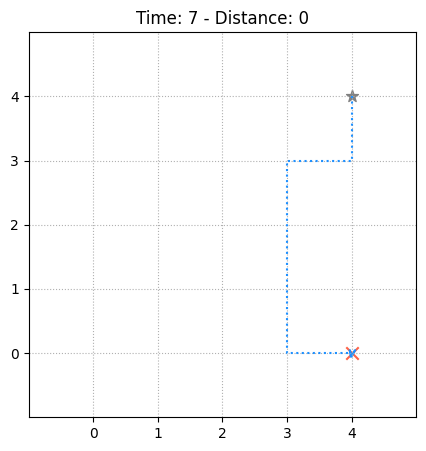

In [29]:
# Visualizar recorrido
graf_grid(env.size, env.time, dist, orig_state, state, trace = np.array(trace))